In [1]:
import numpy as np
import json
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.cit import fisherz
from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge
from causallearn.graph.GraphNode import GraphNode
import time

X_pc_full_cpd = np.load(r"C:\Users\user\Desktop\ai causal\FTND\african_amercian\cpd_pc_input.npy")
with open(r"C:\Users\user\Desktop\ai causal\FTND\african_amercian\cpd_pc_col_names.json") as f:
    col_names_cpd = json.load(f)

n_nodes = len(col_names_cpd)
outcome_idx = col_names_cpd.index("CPD")
print("Input shape:", X_pc_full_cpd.shape)
print("CPD index:", outcome_idx)
print("n_nodes:", n_nodes)

bk = BackgroundKnowledge()
nodes = [GraphNode(name) for name in col_names_cpd]
for i in range(n_nodes - 1):
    bk.add_node_to_tier(nodes[i], 0)
bk.add_node_to_tier(nodes[outcome_idx], 1)

start = time.time()
cg = pc(
    data=X_pc_full_cpd,
    alpha=0.001,
    indep_test=fisherz,
    stable=True,
    uc_rule=0,
    uc_priority=2,
    background_knowledge=bk,
    verbose=False,
    show_progress=True,
    node_names=col_names_cpd
)
elapsed = time.time() - start
print(f"Completed in {elapsed:.1f}s")
print("Nodes:", len(cg.G.nodes))

c:\Users\user\Desktop\ai causal\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Input shape: (1631, 37)
CPD index: 36
n_nodes: 37


Depth=12, working on node 36: 100%|██████████| 37/37 [00:00<00:00, 1867.97it/s]


Completed in 7.2s
Nodes: 37


In [2]:
import networkx as nx

adj = cg.G.graph
edges_directed_cpd = []
edges_undirected_cpd = []

for i in range(n_nodes):
    for j in range(i+1, n_nodes):
        if adj[i,j] == -1 and adj[j,i] == 1:
            edges_directed_cpd.append((col_names_cpd[i], col_names_cpd[j]))
        elif adj[i,j] == 1 and adj[j,i] == -1:
            edges_directed_cpd.append((col_names_cpd[j], col_names_cpd[i]))
        elif adj[i,j] == -1 and adj[j,i] == -1:
            edges_undirected_cpd.append((col_names_cpd[i], col_names_cpd[j]))

print(f"Directed edges: {len(edges_directed_cpd)}")
print(f"Undirected edges: {len(edges_undirected_cpd)}")
print(f"Reverse edges (CPD → SNP): {len([(u,v) for u,v in edges_directed_cpd if u=='CPD'])}")

print("\nEdges involving CPD:")
cpd_snps_aa = []
for u, v in edges_directed_cpd:
    if v == "CPD":
        print(f"  {u} → CPD")
        cpd_snps_aa.append(u)
for u, v in edges_undirected_cpd:
    if "CPD" in (u, v):
        other = v if u == "CPD" else u
        print(f"  {other} --- CPD (undirected)")
        cpd_snps_aa.append(other)

print(f"\nTotal SNPs connected to CPD: {len(cpd_snps_aa)}")

# build ancestral subgraph
G_cpd = nx.DiGraph()
G_cpd.add_nodes_from(col_names_cpd)
for u, v in edges_directed_cpd:
    G_cpd.add_edge(u, v)
G_reach_cpd = G_cpd.copy()
for u, v in edges_undirected_cpd:
    G_reach_cpd.add_edge(u, v)
    G_reach_cpd.add_edge(v, u)

ancestors_cpd = nx.ancestors(G_reach_cpd, "CPD")
ancestors_cpd.add("CPD")
print(f"\nAncestral subgraph nodes: {len(ancestors_cpd)}")

Directed edges: 23
Undirected edges: 18
Reverse edges (CPD → SNP): 0

Edges involving CPD:
  exm2277017-0_T_R_1989215336 → CPD
  exm1567342-0_B_F_1918398641 → CPD
  exm318398-0_B_F_1922126681 → CPD
  exm469871-0_B_F_1921101970 → CPD
  exm479357-0_T_R_1921130751 → CPD

Total SNPs connected to CPD: 5

Ancestral subgraph nodes: 6


In [3]:
import requests
import time
import re
import pandas as pd

MANIFEST = r"C:\Users\user\Downloads\HumanExome-12-v1-0-B.csv"
manifest_df = pd.read_csv(MANIFEST, skiprows=7, low_memory=False)
manifest_df["core_name"] = manifest_df["IlmnID"].map(lambda x: re.sub(r'_\d+$', '', x))
chr_lookup = manifest_df.set_index("core_name")["Chr"]
pos_lookup_m = manifest_df.set_index("core_name")["MapInfo"]

def get_chr(pid):
    if pid == "CPD":
        return "phenotype"
    return str(chr_lookup.get(re.sub(r'_\d+$', '', pid), "?"))

def get_pos(pid):
    val = pos_lookup_m.get(re.sub(r'_\d+$', '', pid), None)
    return int(val) if pd.notna(val) else None

def get_gene_ensembl(chrom, pos, window=50000):
    url = f"https://grch37.rest.ensembl.org/overlap/region/human/{chrom}:{pos-window}-{pos+window}"
    params = {"feature": "gene", "content-type": "application/json"}
    try:
        r = requests.get(url, params=params, timeout=15)
        if r.status_code != 200:
            return "?"
        genes = r.json()
        if not genes:
            return "intergenic"
        coding = [g for g in genes if g.get("biotype") == "protein_coding"]
        targets = coding if coding else genes
        names = list(set(g.get("external_name", "?") for g in targets))
        return " | ".join(names[:3])
    except:
        return "error"

# annotate CPD network SNPs
print("Annotating CPD network SNPs...")
gene_map_cpd = {}
for pid in cpd_snps_aa:
    chrom = get_chr(pid)
    pos = get_pos(pid)
    gene = get_gene_ensembl(chrom, pos)
    gene_map_cpd[pid] = gene
    print(f"  Chr{chrom}:{pos:,} → {gene}")
    time.sleep(0.5)

Annotating CPD network SNPs...
  Chr1:202,399,880 → PPP1R12B
  Chr21:34,860,677 → DNAJC28 | TMEM50B | IFNGR2
  Chr3:50,614,990 → MAPKAPK3 | HEMK1 | C3orf18
  Chr5:102,895,930 → NUDT12
  Chr5:135,392,482 → TGFBI


Final graph — nodes: 6
Directed edges: 5
Undirected edges: 0


C:\Users\user\AppData\Local\Temp\ipykernel_6576\1611512014.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(unique_chroms_cpd))


NameError: name 'os' is not defined

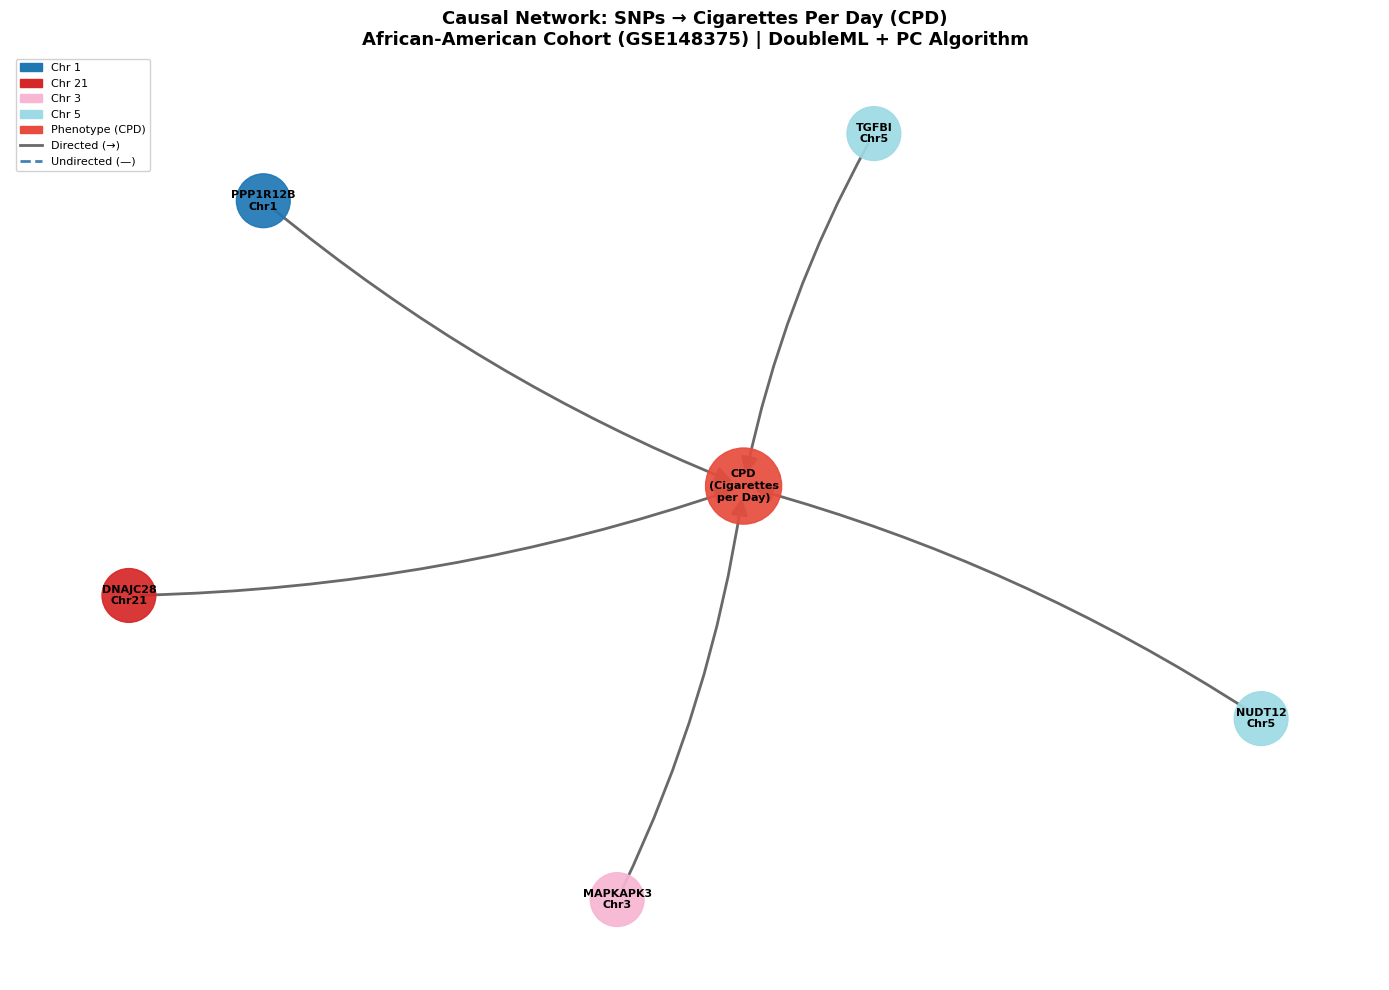

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import numpy as np

# build final graph
G_final_cpd = nx.DiGraph()
G_final_cpd.add_nodes_from(ancestors_cpd)

directed_edges_draw = []
undirected_edges_draw = []
undirected_pairs = set()

for u, v in edges_directed_cpd:
    if u in ancestors_cpd and v in ancestors_cpd:
        G_final_cpd.add_edge(u, v)
        directed_edges_draw.append((u, v))

for u, v in edges_undirected_cpd:
    if u in ancestors_cpd and v in ancestors_cpd:
        if (v, u) not in undirected_pairs:
            undirected_pairs.add((u, v))
            undirected_edges_draw.append((u, v))
        G_final_cpd.add_edge(u, v, undirected=True)
        G_final_cpd.add_edge(v, u, undirected=True)

print("Final graph — nodes:", G_final_cpd.number_of_nodes())
print("Directed edges:", len(directed_edges_draw))
print("Undirected edges:", len(undirected_edges_draw))

# colors
unique_chroms_cpd = sorted(set(get_chr(n) for n in G_final_cpd.nodes()
                                if n != "CPD"))
cmap = plt.cm.get_cmap("tab20", len(unique_chroms_cpd))
chrom_color_cpd = {c: cmap(i) for i, c in enumerate(unique_chroms_cpd)}
chrom_color_cpd["phenotype"] = "#e74c3c"

def make_label_cpd(pid):
    if pid == "CPD":
        return "CPD\n(Cigarettes\nper Day)"
    gene = gene_map_cpd.get(pid, "")
    chrom = get_chr(pid)
    if gene and gene not in ["intergenic", "?", "error"]:
        first_gene = gene.split("|")[0].strip()
        return f"{first_gene}\nChr{chrom}"
    return f"Chr{chrom}\n{pid.split('-')[0]}"

node_colors_cpd = [chrom_color_cpd[get_chr(n)] for n in G_final_cpd.nodes()]
node_sizes_cpd = [3000 if n == "CPD" else 1500 for n in G_final_cpd.nodes()]
node_labels_cpd = {n: make_label_cpd(n) for n in G_final_cpd.nodes()}

# layout — CPD centered
pos_cpd = nx.spring_layout(G_final_cpd, seed=42, k=3.0)
pos_cpd["CPD"] = np.array([0.0, 0.0])
for node in pos_cpd:
    if node != "CPD":
        vec = pos_cpd[node] - np.array([0.0, 0.0])
        dist = np.linalg.norm(vec)
        if dist < 0.4:
            pos_cpd[node] = np.array([0.0, 0.0]) + (vec/dist) * 0.4

plt.figure(figsize=(14, 10))
nx.draw_networkx_nodes(G_final_cpd, pos_cpd, node_color=node_colors_cpd,
                       node_size=node_sizes_cpd, alpha=0.92)
nx.draw_networkx_labels(G_final_cpd, pos_cpd, labels=node_labels_cpd,
                        font_size=8, font_weight="bold")
nx.draw_networkx_edges(G_final_cpd, pos_cpd, edgelist=directed_edges_draw,
                       edge_color="dimgray", arrows=True,
                       arrowsize=25, width=2.0,
                       connectionstyle="arc3,rad=0.08")
nx.draw_networkx_edges(G_final_cpd, pos_cpd, edgelist=undirected_edges_draw,
                       edge_color="steelblue", arrows=False,
                       style="dashed", width=1.5)

legend_patches = [mpatches.Patch(color=chrom_color_cpd[c], label=f"Chr {c}")
                  for c in unique_chroms_cpd]
legend_patches.append(mpatches.Patch(color="#e74c3c", label="Phenotype (CPD)"))
legend_patches.append(plt.Line2D([0],[0], color="dimgray", linewidth=2, label="Directed (→)"))
legend_patches.append(plt.Line2D([0],[0], color="steelblue", linewidth=2,
                                  linestyle="dashed", label="Undirected (—)"))
plt.legend(handles=legend_patches, loc="upper left", fontsize=8, framealpha=0.9)

plt.title("Causal Network: SNPs → Cigarettes Per Day (CPD)\n"
          "African-American Cohort (GSE148375) | DoubleML + PC Algorithm",
          fontsize=13, fontweight="bold")
plt.axis("off")
plt.tight_layout()

OUT_DIR = r"C:\Users\user\Desktop\ai causal\FTND\african_amercian"
out_path = os.path.join(OUT_DIR, "cpd_causal_network_AA.png")
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", out_path)